Cell 1 — Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import random
from collections import defaultdict

random.seed(42)
np.random.seed(42)

plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["axes.grid"] = True
plt.rcParams["font.size"] = 11

Cell 2 — Environment

In [2]:
class TicTacToe:
    """3x3 Tic-Tac-Toe. Players are +1 (X) and -1 (O)."""

    def __init__(self):
        self.reset()

    def reset(self):
        self.board = np.zeros((3, 3), dtype=int)
        self.done = False
        self.winner = None            # +1, -1, 0 (draw) or None
        return self.get_state()

    def get_state(self):
        return tuple(self.board.flatten())

    def available_actions(self):
        return [(r, c) for r in range(3) for c in range(3) if self.board[r, c] == 0]

    def check_winner(self):
        b = self.board
        lines = []
        for i in range(3):
            lines.append(b[i, :].sum())
            lines.append(b[:, i].sum())
        lines.append(np.trace(b))
        lines.append(np.trace(np.fliplr(b)))
        if 3 in lines:
            return 1
        if -3 in lines:
            return -1
        return None

    def make_move(self, action, player):
        r, c = action
        if self.board[r, c] != 0:
            raise ValueError(f"Illegal move at {action}")
        self.board[r, c] = player
        w = self.check_winner()
        if w is not None:
            self.winner, self.done = w, True
        elif len(self.available_actions()) == 0:
            self.winner, self.done = 0, True
        return self.get_state(), self.done, self.winner

    def render(self):
        symbols = {1: "X", -1: "O", 0: "."}
        print("\n".join(" ".join(symbols[v] for v in row) for row in self.board))
        print()

Cell 3 — TD(0) State-Value Agent

In [3]:
class TDAgent:
    """Learns a state-value function V(s) by self-play + TD(0) updates."""

    def __init__(self, symbol, alpha=0.2, gamma=0.9, epsilon=0.2):
        self.symbol = symbol          # +1 for X, -1 for O
        self.alpha = alpha            # learning rate
        self.gamma = gamma            # discount factor
        self.epsilon = epsilon        # exploration rate
        self.default = 0.5            # value of an unseen state
        self.V = {}                   # STATE-VALUE table
        self.states = []              # afterstates visited this episode

    def reset_episode(self):
        self.states = []

    def value(self, state):
        return self.V.get(state, self.default)

    def choose_action(self, env, greedy=False):
        actions = env.available_actions()
        if (not greedy) and random.random() < self.epsilon:
            return random.choice(actions)               # explore
        best_val, best_actions = -np.inf, []
        for a in actions:
            after = env.board.copy()
            after[a] = self.symbol
            v = self.value(tuple(after.flatten()))
            if v > best_val:
                best_val, best_actions = v, [a]
            elif v == best_val:
                best_actions.append(a)
        return random.choice(best_actions)              # exploit (random tie-break)

    def record(self, state):
        self.states.append(state)

    def learn(self, reward):
        target = reward
        for s in reversed(self.states):                 # backward reward propagation
            old = self.value(s)
            self.V[s] = old + self.alpha * (target - old)
            target = self.gamma * self.V[s]
        self.states = []

Cell 4 — Self-play, train(), evaluate()

In [4]:
def play_training_game(env, agentX, agentO):
    env.reset()
    agentX.reset_episode()
    agentO.reset_episode()
    current = 1
    while not env.done:
        agent = agentX if current == 1 else agentO
        action = agent.choose_action(env, greedy=False)
        env.make_move(action, current)
        agent.record(env.get_state())
        current = -current
    if env.winner == 1:
        rX, rO = 1.0, 0.0
    elif env.winner == -1:
        rX, rO = 0.0, 1.0
    else:
        rX, rO = 0.5, 0.5
    agentX.learn(rX)
    agentO.learn(rO)
    return env.winner, rX


def train(agentX, agentO, episodes, env=None, reward_log=None):
    if env is None:
        env = TicTacToe()
    for _ in range(episodes):
        _, rX = play_training_game(env, agentX, agentO)
        if reward_log is not None:
            reward_log.append(rX)
    return agentX, agentO


def evaluate(agent, n_games=1000):
    env = TicTacToe()
    wins = losses = draws = 0
    for _ in range(n_games):
        env.reset()
        current = 1
        while not env.done:
            if current == agent.symbol:
                a = agent.choose_action(env, greedy=True)
            else:
                a = random.choice(env.available_actions())
            env.make_move(a, current)
            current = -current
        if env.winner == agent.symbol:
            wins += 1
        elif env.winner == 0:
            draws += 1
        else:
            losses += 1
    n = float(n_games)
    return 100 * wins / n, 100 * losses / n, 100 * draws / n

Cell 5 — Train across milestones

In [5]:
random.seed(42)
np.random.seed(42)

agentX = TDAgent(symbol=1,  alpha=0.2, gamma=0.9, epsilon=0.2)
agentO = TDAgent(symbol=-1, alpha=0.2, gamma=0.9, epsilon=0.2)

shared_env = TicTacToe()
milestones = [100, 500, 1000, 5000, 10000]

records = []
reward_history = []

trained_so_far = 0
for m in milestones:
    train(agentX, agentO, m - trained_so_far, env=shared_env, reward_log=reward_history)
    trained_so_far = m
    win, loss, draw = evaluate(agentX, n_games=1000)
    records.append({"Episodes": m, "Win %": round(win, 1),
                    "Loss %": round(loss, 1), "Draw %": round(draw, 1)})
    print(f"Episodes {m:>5} | Win {win:5.1f}%  Loss {loss:5.1f}%  Draw {draw:5.1f}%")

results_df = pd.DataFrame(records)[["Episodes", "Win %", "Loss %", "Draw %"]]
results_df

Episodes   100 | Win  67.2%  Loss  21.7%  Draw  11.1%
Episodes   500 | Win  88.5%  Loss   8.3%  Draw   3.2%
Episodes  1000 | Win  90.3%  Loss   6.4%  Draw   3.3%
Episodes  5000 | Win  99.1%  Loss   0.0%  Draw   0.9%
Episodes 10000 | Win  98.9%  Loss   0.0%  Draw   1.1%


,Episodes,Win %,Loss %,Draw %
0,100,67.2,21.7,11.1
1,500,88.5,8.3,3.2
2,1000,90.3,6.4,3.3
3,5000,99.1,0.0,0.9
4,10000,98.9,0.0,1.1


Cell 6 — Graphs

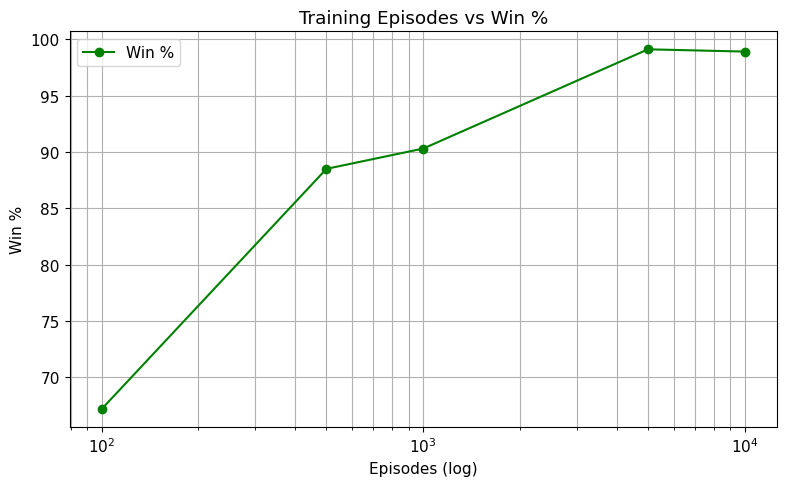

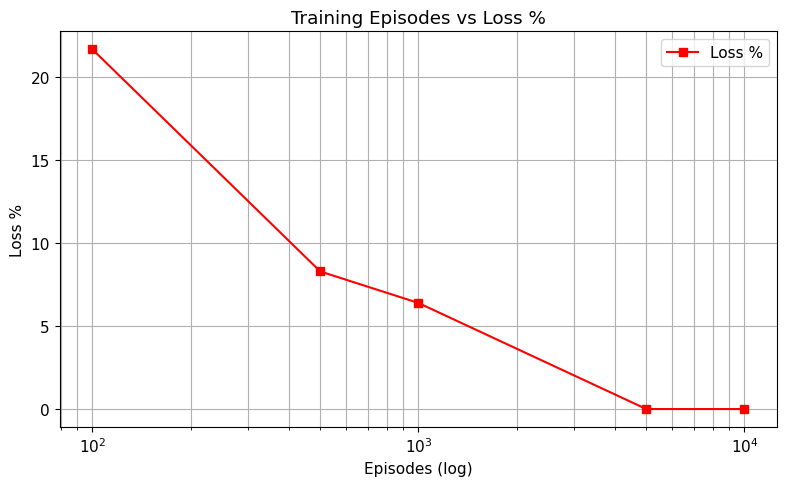

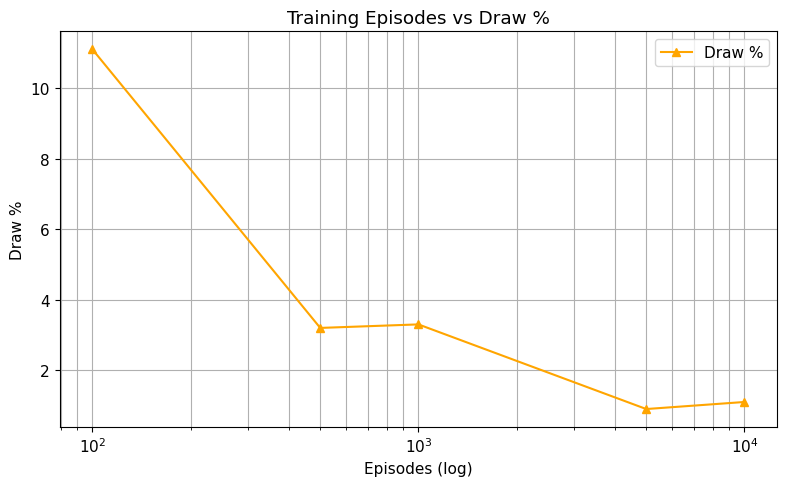

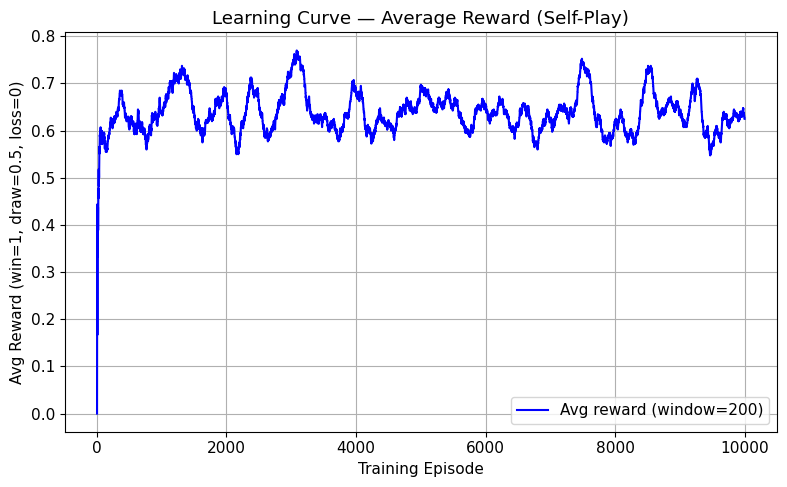

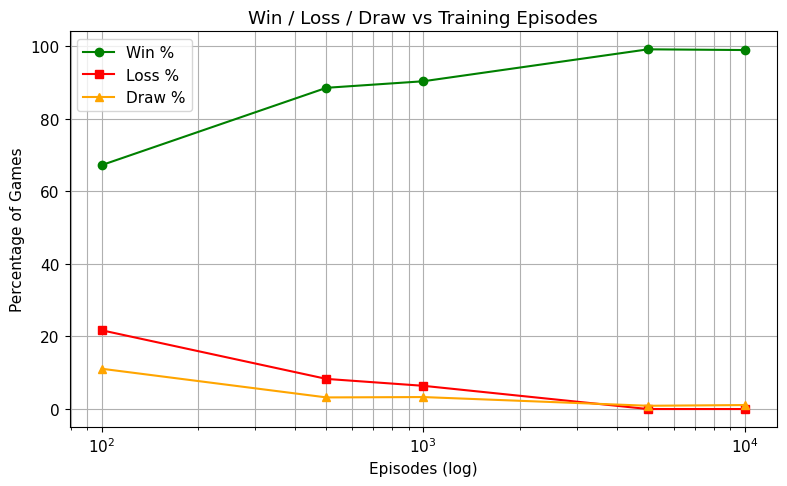

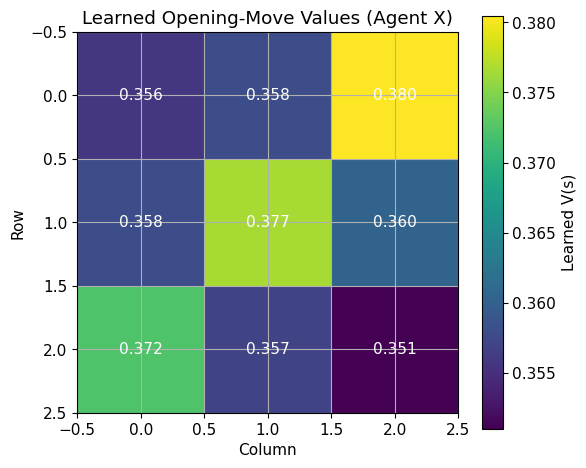

In [6]:
# Graph 1: Win %
plt.figure()
plt.plot(results_df["Episodes"], results_df["Win %"], marker="o", color="green", label="Win %")
plt.xscale("log")
plt.title("Training Episodes vs Win %"); plt.xlabel("Episodes (log)"); plt.ylabel("Win %")
plt.legend(); plt.grid(True, which="both"); plt.tight_layout(); plt.show()

# Graph 2: Loss %
plt.figure()
plt.plot(results_df["Episodes"], results_df["Loss %"], marker="s", color="red", label="Loss %")
plt.xscale("log")
plt.title("Training Episodes vs Loss %"); plt.xlabel("Episodes (log)"); plt.ylabel("Loss %")
plt.legend(); plt.grid(True, which="both"); plt.tight_layout(); plt.show()

# Graph 3: Draw %
plt.figure()
plt.plot(results_df["Episodes"], results_df["Draw %"], marker="^", color="orange", label="Draw %")
plt.xscale("log")
plt.title("Training Episodes vs Draw %"); plt.xlabel("Episodes (log)"); plt.ylabel("Draw %")
plt.legend(); plt.grid(True, which="both"); plt.tight_layout(); plt.show()

# Graph 4: Learning curve (rolling avg reward)
window = 200
moving_avg = pd.Series(reward_history).rolling(window, min_periods=1).mean()
plt.figure()
plt.plot(range(1, len(moving_avg) + 1), moving_avg, color="blue",
         label=f"Avg reward (window={window})")
plt.title("Learning Curve — Average Reward (Self-Play)")
plt.xlabel("Training Episode"); plt.ylabel("Avg Reward (win=1, draw=0.5, loss=0)")
plt.legend(); plt.grid(True); plt.tight_layout(); plt.show()

# Graph 5: Combined
plt.figure()
plt.plot(results_df["Episodes"], results_df["Win %"],  marker="o", color="green",  label="Win %")
plt.plot(results_df["Episodes"], results_df["Loss %"], marker="s", color="red",    label="Loss %")
plt.plot(results_df["Episodes"], results_df["Draw %"], marker="^", color="orange", label="Draw %")
plt.xscale("log")
plt.title("Win / Loss / Draw vs Training Episodes")
plt.xlabel("Episodes (log)"); plt.ylabel("Percentage of Games")
plt.legend(); plt.grid(True, which="both"); plt.tight_layout(); plt.show()

# Optional: heatmap of learned opening-move values
empty = np.zeros((3, 3), dtype=int)
opening_values = np.zeros((3, 3))
for r in range(3):
    for c in range(3):
        b = empty.copy(); b[r, c] = 1
        opening_values[r, c] = agentX.value(tuple(b.flatten()))
plt.figure(figsize=(6, 5))
im = plt.imshow(opening_values, cmap="viridis")
plt.colorbar(im, label="Learned V(s)")
plt.title("Learned Opening-Move Values (Agent X)")
plt.xlabel("Column"); plt.ylabel("Row")
for r in range(3):
    for c in range(3):
        plt.text(c, r, f"{opening_values[r, c]:.3f}", ha="center", va="center",
                 color="white", fontsize=11)
plt.tight_layout(); plt.show()

Cell 7 — Observations & Conclusion

In [7]:
row = {int(r["Episodes"]): r for _, r in results_df.iterrows()}
notes = {
    100:   "behaves mostly randomly — value table still sparse.",
    500:   "begins blocking the opponent and avoiding obvious losses.",
    1000:  "starts choosing stronger positions (centre/corners).",
    5000:  "rarely loses — value estimates close to converged.",
    10000: "approaches optimal play, winning almost every game.",
}
print("OBSERVATIONS\n" + "=" * 60)
for ep in milestones:
    r = row[ep]
    print(f"At {ep:>5} episodes -> Win {r['Win %']:5.1f}%  Loss {r['Loss %']:5.1f}%  Draw {r['Draw %']:5.1f}%")
    print("   " + notes[ep])

first, last = row[milestones[0]], row[milestones[-1]]
print(f"\nCONCLUSION\n{'-'*60}")
print(f"Using TD(0) STATE-VALUE self-play (not Q-learning), win rate rose from "
      f"{first['Win %']:.1f}% to {last['Win %']:.1f}% and loss rate fell from "
      f"{first['Loss %']:.1f}% to {last['Loss %']:.1f}% as training grew from "
      f"{milestones[0]} to {milestones[-1]} episodes. More episodes let the value "
      f"estimates converge, so the agent progressed from near-random play to "
      f"near-optimal play purely from self-play rewards.")

OBSERVATIONS
At   100 episodes -> Win  67.2%  Loss  21.7%  Draw  11.1%
   behaves mostly randomly — value table still sparse.
At   500 episodes -> Win  88.5%  Loss   8.3%  Draw   3.2%
   begins blocking the opponent and avoiding obvious losses.
At  1000 episodes -> Win  90.3%  Loss   6.4%  Draw   3.3%
   starts choosing stronger positions (centre/corners).
At  5000 episodes -> Win  99.1%  Loss   0.0%  Draw   0.9%
   rarely loses — value estimates close to converged.
At 10000 episodes -> Win  98.9%  Loss   0.0%  Draw   1.1%
   approaches optimal play, winning almost every game.

CONCLUSION
------------------------------------------------------------
Using TD(0) STATE-VALUE self-play (not Q-learning), win rate rose from 67.2% to 98.9% and loss rate fell from 21.7% to 0.0% as training grew from 100 to 10000 episodes. More episodes let the value estimates converge, so the agent progressed from near-random play to near-optimal play purely from self-play rewards.
